# Feature Engineering

Exploring the 18 hand-crafted features we use for issue classification.
Goal: see if features actually separate different degradation types.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from config import DATA_DIR, IMG_SIZE
from ml.features import extract_features, ImageFeatures

sns.set_theme(style="darkgrid")
DATA_GEN = DATA_DIR / "generated"

## Extract features from samples

In [2]:
def get_features(split, max_n=2000):
    meta = pd.read_csv(DATA_GEN / split / "metadata.csv")
    img_dir = DATA_GEN / split / "images"
    if len(meta) > max_n:
        meta = meta.sample(max_n, random_state=42).reset_index(drop=True)
    
    rows = []
    for _, r in tqdm(meta.iterrows(), total=len(meta), desc=split):
        img = cv2.imread(str(img_dir / r['filename']))
        if img is None: continue
        f = extract_features(img)
        d = dict(zip(f.names(), f.to_vector()))
        d['degradation_type'] = r['degradation_type']
        d['severity'] = r['severity']
        d['quality_score'] = r['quality_score']
        rows.append(d)
    return pd.DataFrame(rows)

train_f = get_features("train", 2000)
test_f = get_features("test", 500)
print(f"Train: {train_f.shape}, Test: {test_f.shape}")

test: 100%|██████████| 500/500 [00:08<00:00, 58.71it/s]

Train: (2000, 21), Test: (500, 21)


## Feature distributions per degradation type

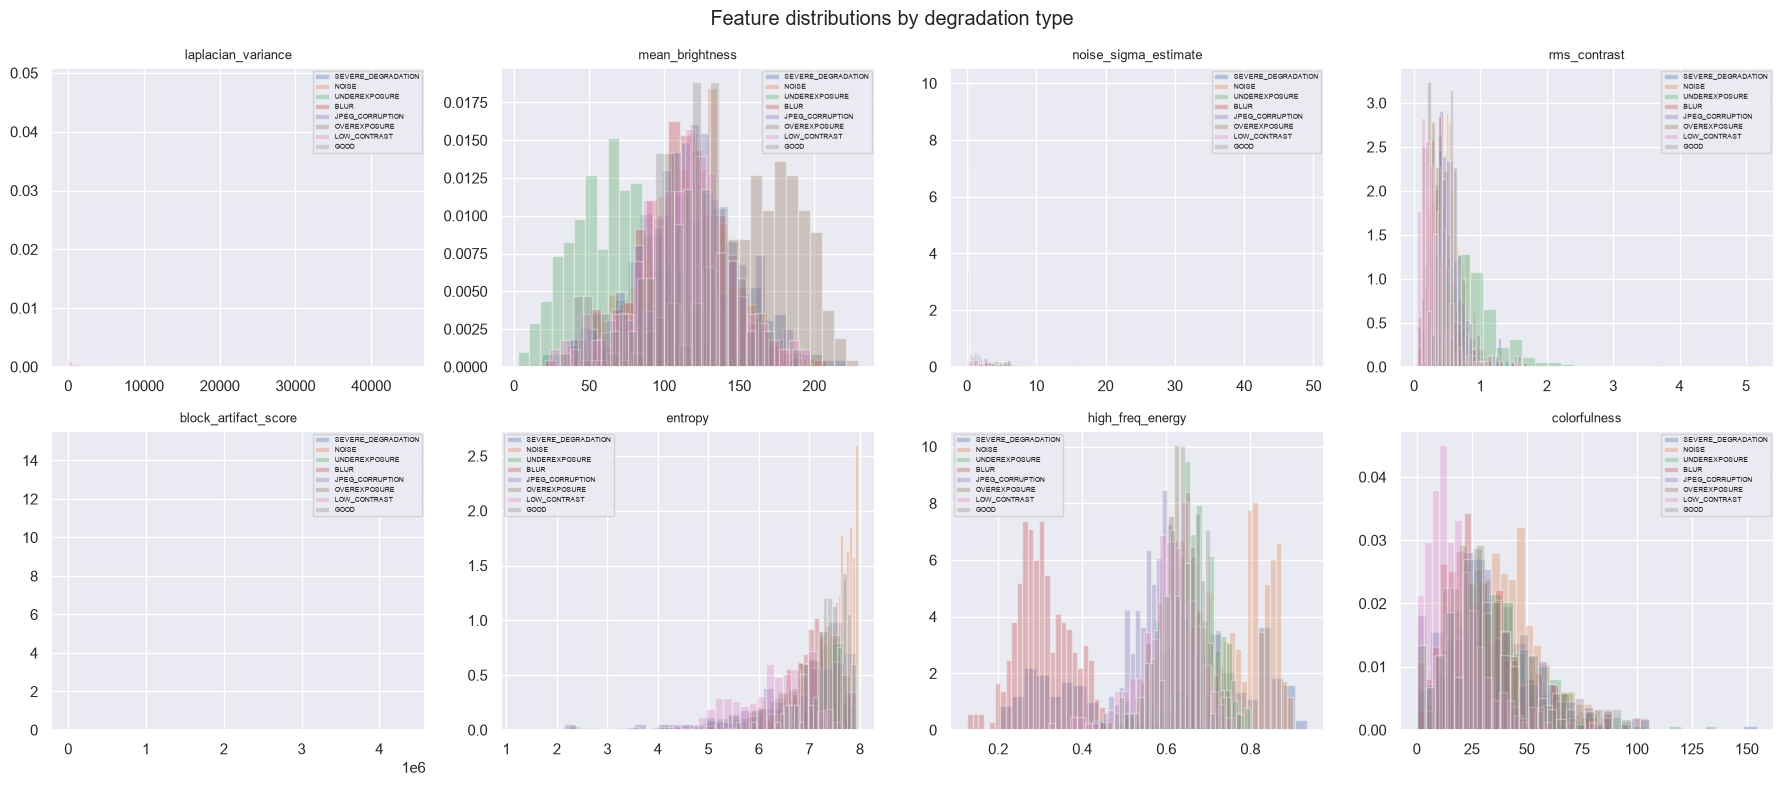

In [3]:
keys = ['laplacian_variance', 'mean_brightness', 'noise_sigma_estimate',
        'rms_contrast', 'block_artifact_score', 'entropy', 'high_freq_energy', 'colorfulness']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), keys):
    for dt in train_f['degradation_type'].unique():
        ax.hist(train_f[train_f['degradation_type'] == dt][feat], bins=25, alpha=0.35, label=dt, density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=5)
plt.suptitle("Feature distributions by degradation type")
plt.tight_layout()
plt.savefig(str(DATA_GEN / "feature_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

## Correlation matrix

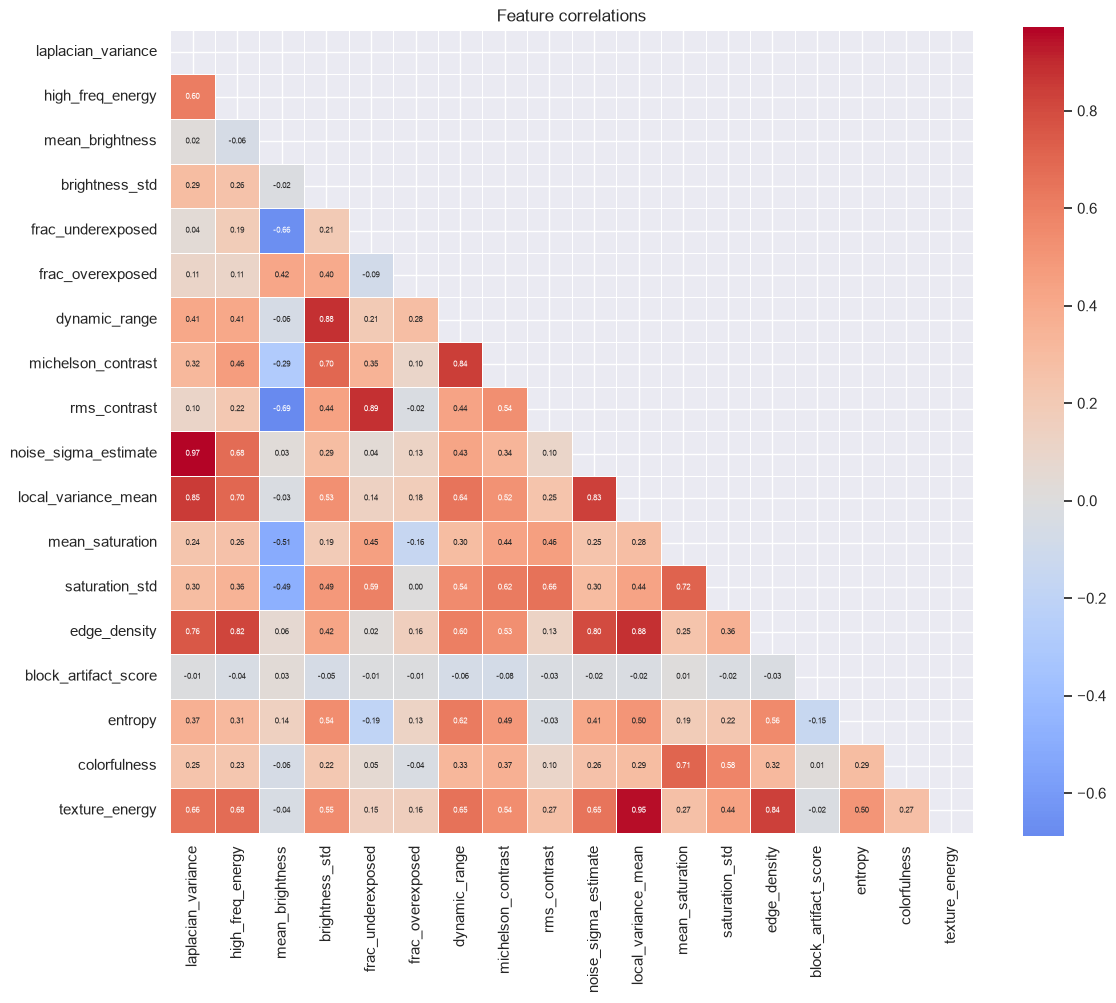

  laplacian_variance ↔ noise_sigma_estimate: 0.973
  laplacian_variance ↔ local_variance_mean: 0.854
  laplacian_variance ↔ edge_density: 0.758
  high_freq_energy ↔ edge_density: 0.822
  brightness_std ↔ dynamic_range: 0.879
  frac_underexposed ↔ rms_contrast: 0.886
  dynamic_range ↔ michelson_contrast: 0.844
  noise_sigma_estimate ↔ local_variance_mean: 0.833
  noise_sigma_estimate ↔ edge_density: 0.802
  local_variance_mean ↔ edge_density: 0.876
  local_variance_mean ↔ texture_energy: 0.949
  mean_saturation ↔ saturation_std: 0.717
  mean_saturation ↔ colorfulness: 0.710
  edge_density ↔ texture_energy: 0.841


In [4]:
feat_cols = ImageFeatures.names()
corr = train_f[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 6})
ax.set_title('Feature correlations')
plt.tight_layout()
plt.savefig(str(DATA_GEN / "feature_correlation.png"), dpi=150, bbox_inches='tight')
plt.show()

# highly correlated pairs
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {feat_cols[i]} ↔ {feat_cols[j]}: {corr.iloc[i, j]:.3f}")

## Feature vs quality score

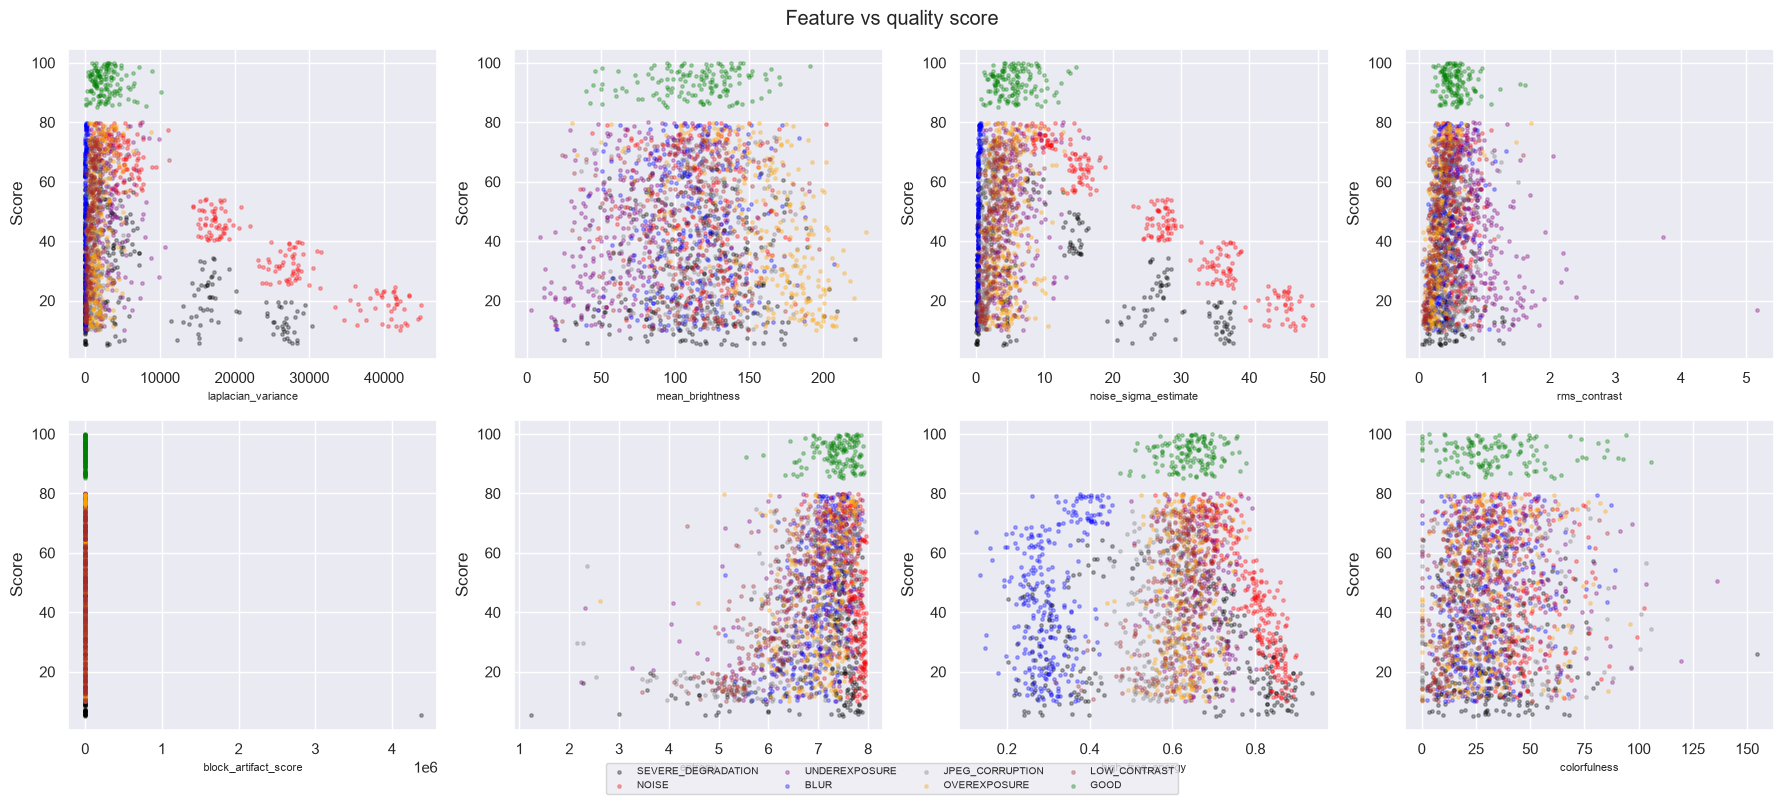

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = {'GOOD': 'green', 'BLUR': 'blue', 'NOISE': 'red', 'UNDEREXPOSURE': 'purple',
          'OVEREXPOSURE': 'orange', 'LOW_CONTRAST': 'brown', 'JPEG_CORRUPTION': 'gray',
          'SEVERE_DEGRADATION': 'black'}

for ax, feat in zip(axes.flatten(), keys):
    for dt in train_f['degradation_type'].unique():
        sub = train_f[train_f['degradation_type'] == dt]
        ax.scatter(sub[feat], sub['quality_score'], alpha=0.3, s=6, c=colors.get(dt, 'gray'), label=dt)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('Score')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=7)
plt.suptitle("Feature vs quality score")
plt.tight_layout()
plt.savefig(str(DATA_GEN / "feature_vs_quality.png"), dpi=150, bbox_inches='tight')
plt.show()

## Box plots — can features separate issues?

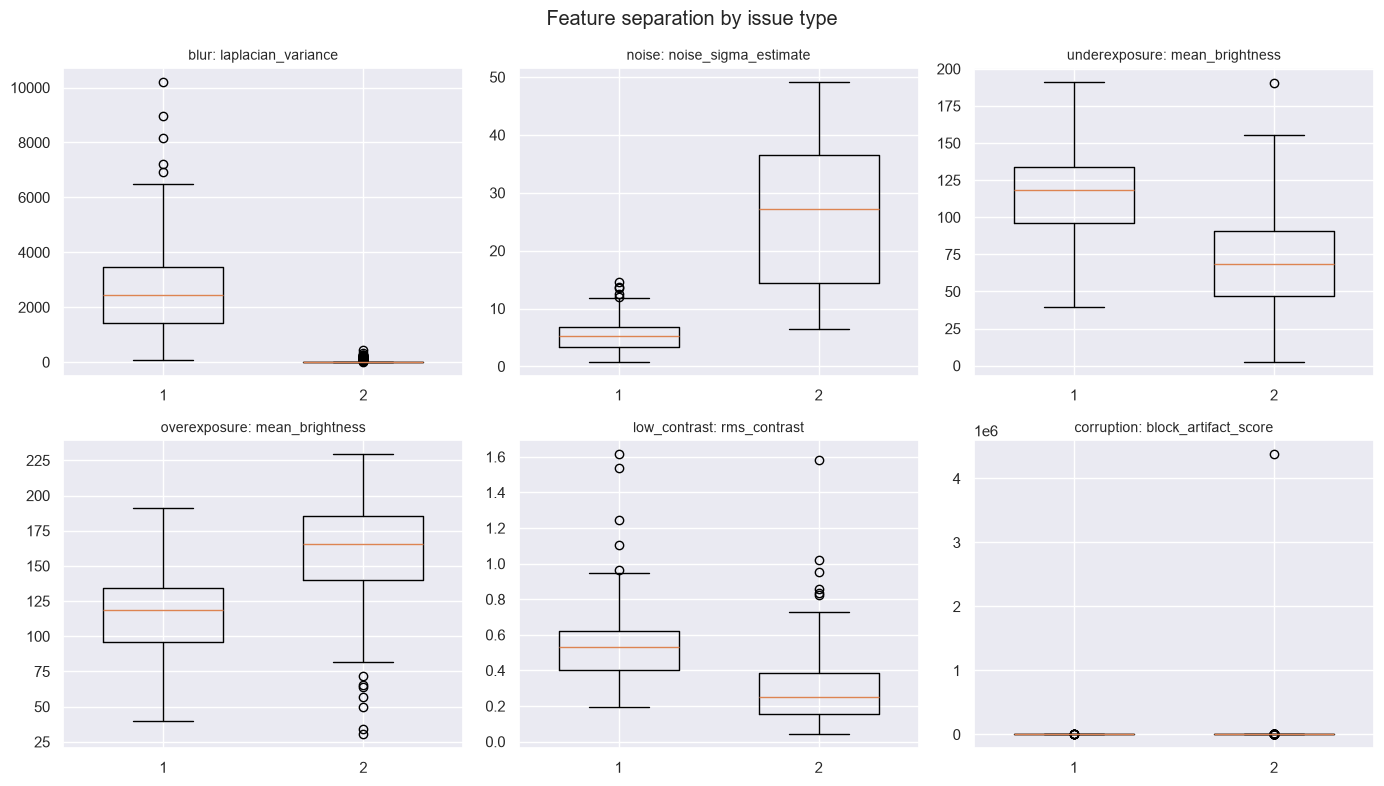

In [7]:
issue_feats = {
    'blur': 'laplacian_variance', 'noise': 'noise_sigma_estimate',
    'underexposure': 'mean_brightness', 'overexposure': 'mean_brightness',
    'low_contrast': 'rms_contrast', 'corruption': 'block_artifact_score',
}

deg_map = {'blur': 'BLUR', 'noise': 'NOISE', 'underexposure': 'UNDEREXPOSURE',
           'overexposure': 'OVEREXPOSURE', 'low_contrast': 'LOW_CONTRAST',
           'corruption': ['JPEG_CORRUPTION', 'SEVERE_DEGRADATION']}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (issue, feat) in zip(axes.flatten(), issue_feats.items()):
    dt = deg_map[issue]
    if isinstance(dt, list):
        pos = train_f[train_f['degradation_type'].isin(dt)][feat]
    else:
        pos = train_f[train_f['degradation_type'] == dt][feat]
    neg = train_f[train_f['degradation_type'] == 'GOOD'][feat]
    ax.boxplot([neg, pos], label=['Clean', issue.upper()], widths=0.6)
    ax.set_title(f'{issue}: {feat}', fontsize=10)

plt.suptitle("Feature separation by issue type")
plt.tight_layout()
plt.savefig(str(DATA_GEN / "feature_separation.png"), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
summary = train_f[feat_cols].describe().T[['mean', 'std', 'min', 'max']]
summary.to_csv(str(DATA_GEN / "feature_summary.csv"))
print(summary.round(2))

                         mean       std    min         max
laplacian_variance    4386.37   8188.35   1.04    44919.89
high_freq_energy         0.60      0.16   0.13        0.94
mean_brightness        114.09     39.36   2.45      229.18
brightness_std          48.71     17.40   6.37       97.98
frac_underexposed        0.08      0.15   0.00        0.98
frac_overexposed         0.03      0.06   0.00        0.52
dynamic_range          186.23     55.38  24.00      255.00
michelson_contrast       0.85      0.21   0.12        1.00
rms_contrast             0.50      0.32   0.04        5.17
noise_sigma_estimate     7.19     10.39   0.03       49.14
local_variance_mean    521.47    511.93   0.37     2809.64
mean_saturation         69.72     44.27   0.00      244.02
saturation_std          44.84     23.41   0.00      116.59
edge_density             0.14      0.11   0.00        0.38
block_artifact_score  2189.04  97827.94   0.57  4375000.00
entropy                  6.92      0.87   1.22        7.